In [13]:
import os
import cv2
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
import joblib


In [2]:
import sklearn
print(sklearn.__version__)


1.2.2


In [3]:
def load_images(folder):
    data = []
    labels = []
    for label_name in ['cat', 'dog']:
        label = 0 if label_name == 'cat' else 1
        folder_path = os.path.join(folder, label_name)
        for file_name in os.listdir(folder_path):
            file_path = os.path.join(folder_path, file_name)
            img = cv2.imread(file_path)
            if img is None:
                continue
            img = cv2.resize(img, (64, 64))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = img.flatten() / 255.0
            data.append(img)
            labels.append(label)
    return np.array(data), np.array(labels)

In [4]:
train_dir = r"C:\Users\thuuy\_python\ml\data_folder\train"
test_dir = r"C:\Users\thuuy\_python\ml\data_folder\test"
val_dir = r"C:\Users\thuuy\_python\ml\data_folder\val"
X_train, y_train = load_images(train_dir)
X_val, y_val     = load_images(val_dir)
X_test, y_test   = load_images(test_dir)

In [5]:

X_search, _, y_search, _ = train_test_split(X_train, y_train, train_size=0.1, stratify=y_train, random_state=42)

param_dist = {
    'n_estimators': [100, 120, 150, 200, 250, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True, False]
}
rfc = RandomForestClassifier(random_state=42, n_jobs=-1)
random_search = RandomizedSearchCV(
    estimator=rfc,
    param_distributions=param_dist,
    n_iter=5,
    cv=2,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [6]:
random_search.fit(X_search, y_search)
print("Best parameters found:")
print(random_search.best_params_)

Fitting 2 folds for each of 5 candidates, totalling 10 fits
Best parameters found:
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 10, 'bootstrap': True}


In [7]:
rfc_model =random_search.best_estimator_
rfc_model.fit(X_train, y_train)

y_val_pred =rfc_model.predict(X_val)
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))

Validation Accuracy: 0.6504


In [8]:
y_test_pred = rfc_model.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))

Test Accuracy: 0.654



Classification Report on Test Set:

              precision    recall  f1-score   support

         Cat       0.67      0.62      0.65      1267
         Dog       0.64      0.69      0.66      1233

    accuracy                           0.65      2500
   macro avg       0.65      0.65      0.65      2500
weighted avg       0.66      0.65      0.65      2500

Confusion Matrix:
 [[790 477]
 [388 845]]
Confusion matrix saved to rfc_confusion_matrix.png


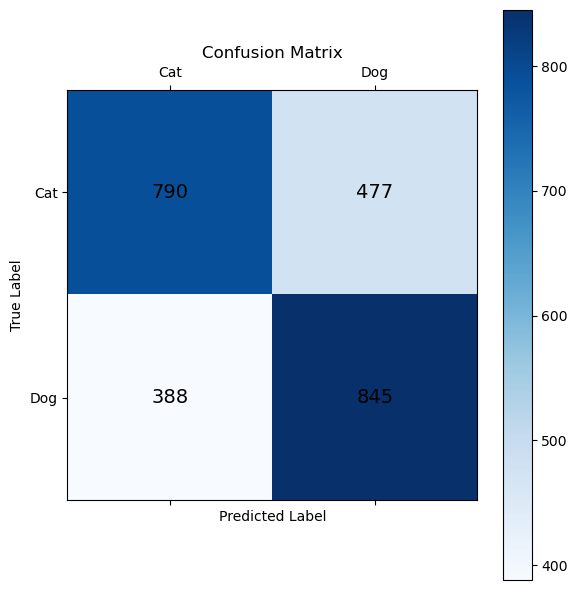

In [9]:
from sklearn.metrics import classification_report
print("\nClassification Report on Test Set:\n")
print(classification_report(y_test, y_test_pred, target_names=['Cat', 'Dog']))

cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:\n", cm)

def plot_confusion_matrix(cm, class_names, save_path='rfc_confusion_matrix.png'):
    fig, ax = plt.subplots(figsize=(6,6))
    cax = ax.matshow(cm, cmap='Blues')
    plt.colorbar(cax)
    for (i, j), val in np.ndenumerate(cm):
        ax.text(j, i, str(val), ha='center', va='center', fontsize=14)
    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path)  
        print(f"Confusion matrix saved to {save_path}")
    plt.show()

plot_confusion_matrix(cm, ['Cat', 'Dog'])

In [14]:
joblib.dump(rfc_model, "rfc_model.pkl")
print("Saved model to rfc_model.pkl")

Saved model to rfc_model.pkl
